In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/Wk 7 ST1 Tutorial & Computer Lab/Assets folder /insects dataset/train_data'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")


Loading dataset with 80/20 train-validation split...
Found 128 files belonging to 3 classes.
Using 103 files for training.
Found 128 files belonging to 3 classes.
Using 25 files for validation.
Classes found: ['Species1', 'Species2', 'Species3']


Step1_Explanation: In step 1, the dataset is loaded from Google Drive and automatically organised into training and validation sets using an 80/20 split. TensorFlow reads the images from the three species folders, resizes them to a consistent input shape, and assigns labels based on the folder names. The output confirms that 125 images were detected and correctly divided into 100 training images and 25 validation images across the three classes. This step prepares the data in a structured format that the model can use for training and evaluation.

Step 2

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Step 3

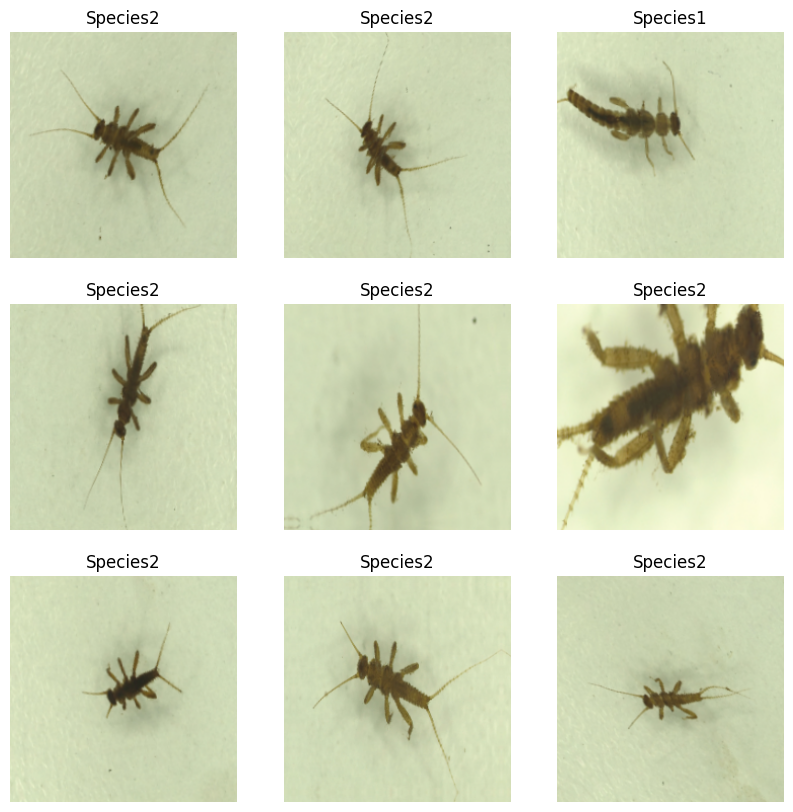

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Step3_Explanation: In step 3, the code creates  changes to the training images, like flipping, rotating, and zooming them. This helps the model learn better because it sees many different versions of the same insect. The code then shows a grid of these augmented images so you can check that the transformations are working.

Step 4

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step4_Explanation: In step 4, the code builds a model by starting with MobileNetV2, which already knows how to recognise basic shapes and patterns from a large image dataset. Images are augmented, preprocessed, passed through the base model, and then reduced to important features. A  layer predicts the species, and the model is compiled so it can be trained in the next step.

Step 5

In [22]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8932 - loss: 0.2183 - val_accuracy: 0.9200 - val_loss: 0.1693
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9709 - loss: 0.1833 - val_accuracy: 0.9200 - val_loss: 0.1974
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9515 - loss: 0.1705 - val_accuracy: 0.9200 - val_loss: 0.1865
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9709 - loss: 0.1598 - val_accuracy: 0.9600 - val_loss: 0.1398
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9515 - loss: 0.1569 - val_accuracy: 0.9600 - val_loss: 0.1023
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9417 - loss: 0.1761 - val_accuracy: 1.0000 - val_loss: 0.0880
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9515 - loss: 0.1397 - val_accuracy: 1.0000 - val_loss: 0.0840
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9515 - loss: 0.1075 - val_accuracy: 1.0000 - val_loss: 0.0873
Epoch 9/10
4/4

Step5_Explanation: In step 5, the model is trained on the insect images for 10 full rounds, called epochs. During this process, the model keeps adjusting its internal weights so it can better recognise each species. The validation set is checked after each epoch to see how well the model performs on new, unseen images.

Step 6

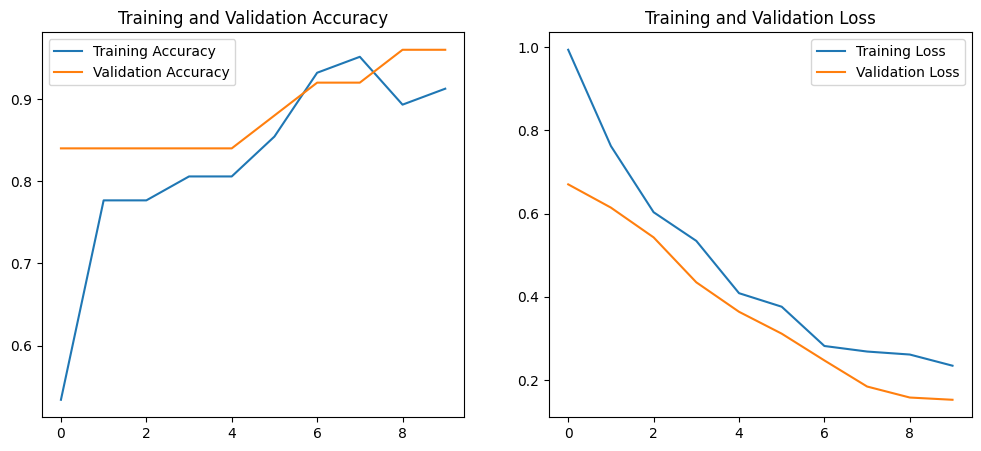

In [18]:
# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

Step6_Explanation: In step 6, the model’s performance is evaluated using the validation dataset. The code calculates important metrics like precision, recall, and F1‑score to show how well the model identifies each insect species.

Step 7

In [19]:
val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9600 - loss: 0.1529
Validation accuracy: 96.00%


Step7_Explanation: The model.evaluate() function calculates the validation loss and accuracy using the trained model. The printed result shows final validation accuracy as a percentage, which tells how often the model predicted the correct species.


Step 9

In [20]:
%cd /content/drive/MyDrive/Wk 7 ST1 Tutorial & Computer Lab
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

/content/drive/MyDrive/Wk 7 ST1 Tutorial & Computer Lab
Model saved as 'macroinvertebrates_classifier.h5'


Step9_Explanation: The model.save() function stores the trained model as a .h5 file, which keeps all the learned weights and structure. This allows to reuse the model later without retraining it.


Step 10

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (3).

<Figure size 1200x1200 with 0 Axes>

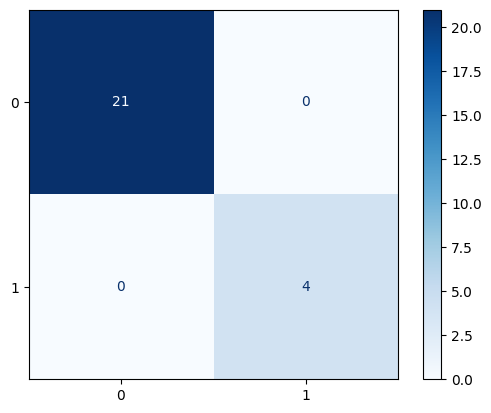

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()


Step10_Explanation: A confusion matrix is created to show where the model predicted correctly and where it made mistakes. The code then calculates weighted precision, recall, and F1‑score to give a balanced view of the model’s overall performance.

Step 12

In [21]:
#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/Wk 7 ST1 Tutorial & Computer Lab/Assets folder /insects dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)

Output hidden; open in https://colab.research.google.com to view.

Step12_Explanation: In step 12, the code loads images from the test folder and prepares them so the trained model can make predictions. Each image is resized, converted to an array, and normalised before being passed into the model. Finally, the original image is displayed along with the predicted label.